Install libraries:

In [11]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn streamlit joblib

Import the required libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load the dataset

In [13]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

Check Dataset Shape

In [14]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1470, 35)


Display the First 5 Rows

In [15]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


View Column Names

In [16]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

Check Data Types

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Check Missing Values

In [18]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


Statistical Summary

In [19]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


Check Target Variable Distribution

In [20]:
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


This indicates the dataset is imbalanced, so we'll address this later using SMOTE.

Check Duplicate Rows

In [21]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


Separate Numerical and Categorical Columns

Numerical Features

In [22]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns

print(numerical_cols)

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


Categorical Features

In [23]:
categorical_cols = df.select_dtypes(include=["object"]).columns

print(categorical_cols)

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


Basic Summary

In [24]:
print(f"Total Employees: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
print(f"Numerical Features: {len(numerical_cols)}")
print(f"Categorical Features: {len(categorical_cols)}")

Total Employees: 1470
Total Features: 35
Numerical Features: 26
Categorical Features: 9


Exploratory Data Analysis (EDA)

Objective: Understand the data, identify patterns related to employee attrition, and gather insights that can guide preprocessing and model selection.

Import Visualization Libraries

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

Overall Attrition Distribution

/tmp/ipykernel_441/692423429.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Attrition", palette="Set2")


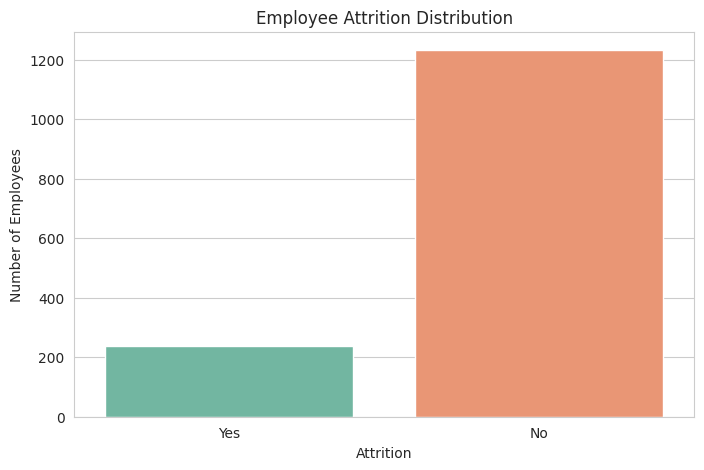

In [26]:
sns.countplot(data=df, x="Attrition", palette="Set2")
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

Observation:

Most employees stayed.
The dataset is imbalanced, with fewer employees leaving.

Attrition Percentage

In [27]:
attrition = df["Attrition"].value_counts(normalize=True) * 100
print(attrition)

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


Gender Distribution

/tmp/ipykernel_441/886983589.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Gender", palette="Pastel1")


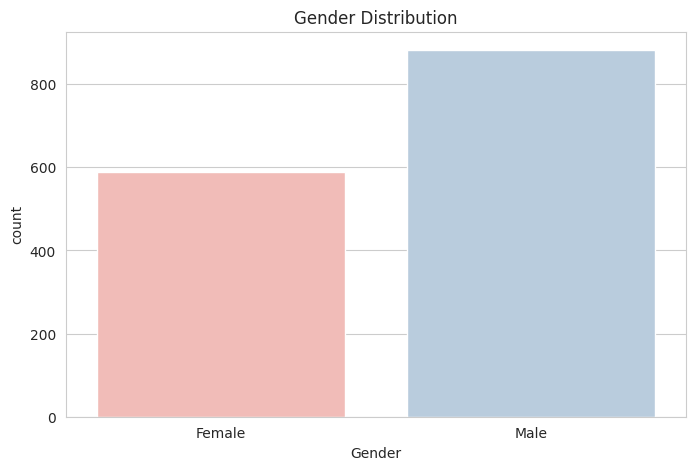

In [28]:
sns.countplot(data=df, x="Gender", palette="Pastel1")
plt.title("Gender Distribution")
plt.show()

Attrition by Gender

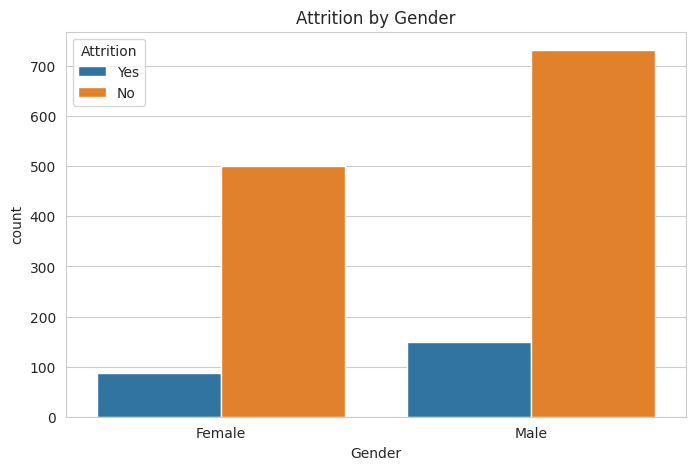

In [29]:
sns.countplot(data=df, x="Gender", hue="Attrition")
plt.title("Attrition by Gender")
plt.show()

Observation:

Compare attrition counts between male and female employees.
Later, calculate percentages to account for different group sizes.

Overtime vs Attrition

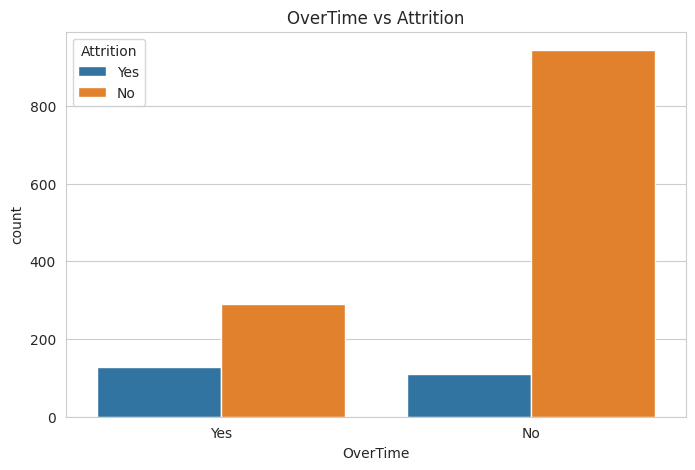

In [30]:
sns.countplot(data=df, x="OverTime", hue="Attrition")
plt.title("OverTime vs Attrition")
plt.show()

Observation:

Employees working overtime often have higher attrition.

Job Role Distribution

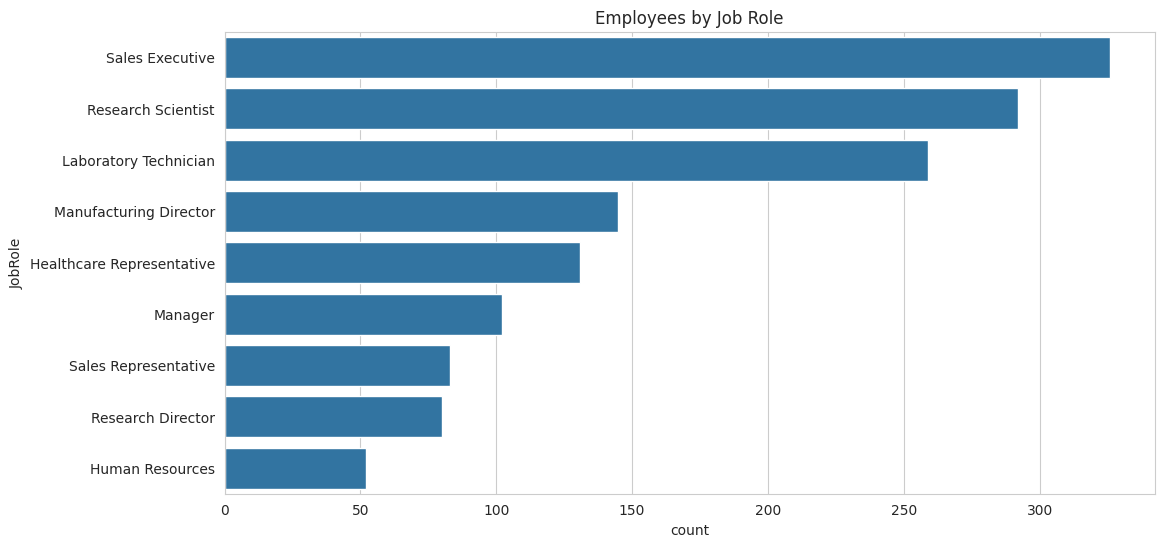

In [31]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="JobRole",
    order=df["JobRole"].value_counts().index
)

plt.title("Employees by Job Role")
plt.show()

Job Role vs Attrition

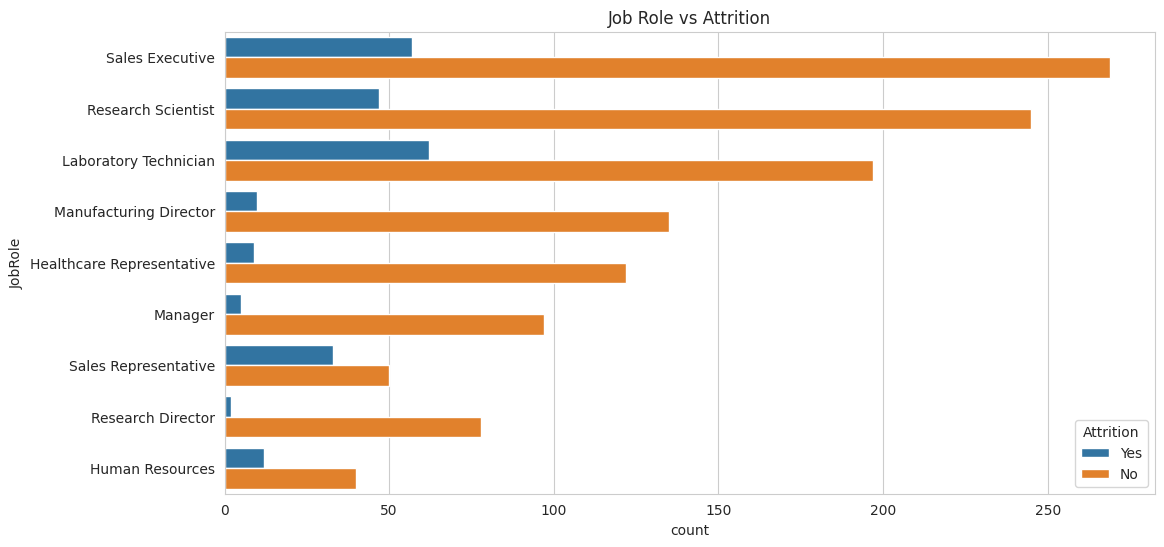

In [32]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="JobRole",
    hue="Attrition",
    order=df["JobRole"].value_counts().index
)

plt.title("Job Role vs Attrition")
plt.show()

Monthly Income Distribution

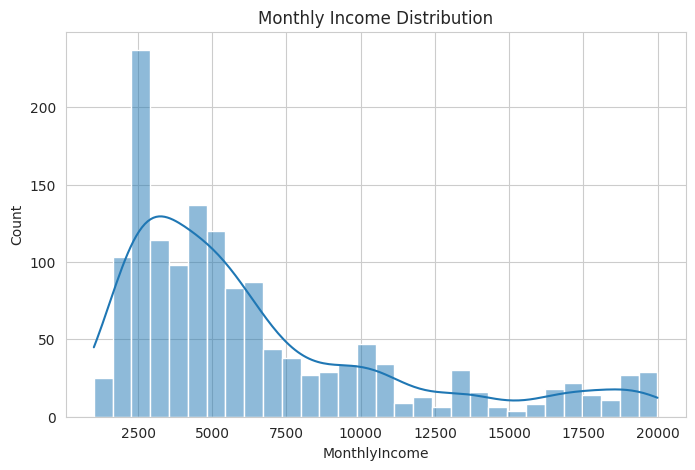

In [33]:
sns.histplot(df["MonthlyIncome"], bins=30, kde=True)

plt.title("Monthly Income Distribution")
plt.show()

Monthly Income vs Attrition

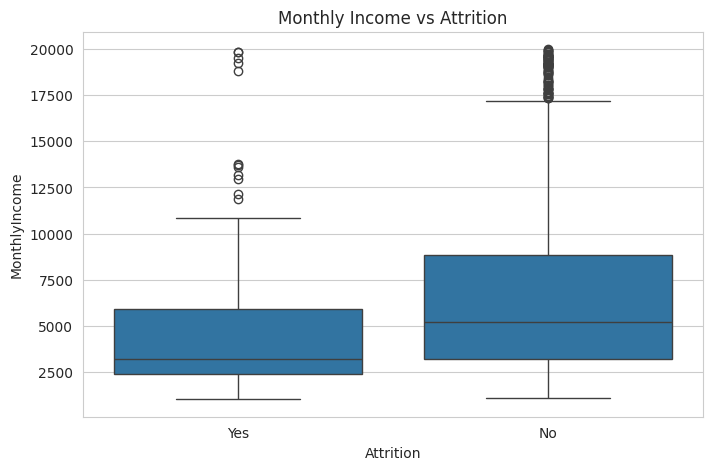

In [34]:
sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income vs Attrition")
plt.show()

Age Distribution

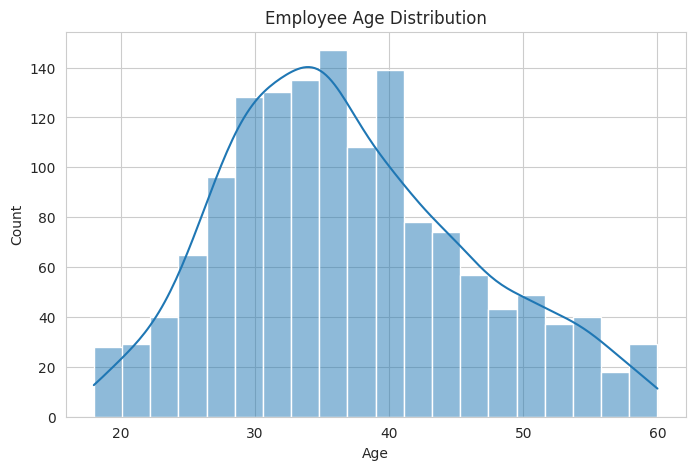

In [35]:
sns.histplot(
    data=df,
    x="Age",
    bins=20,
    kde=True
)

plt.title("Employee Age Distribution")
plt.show()

Age vs Attrition

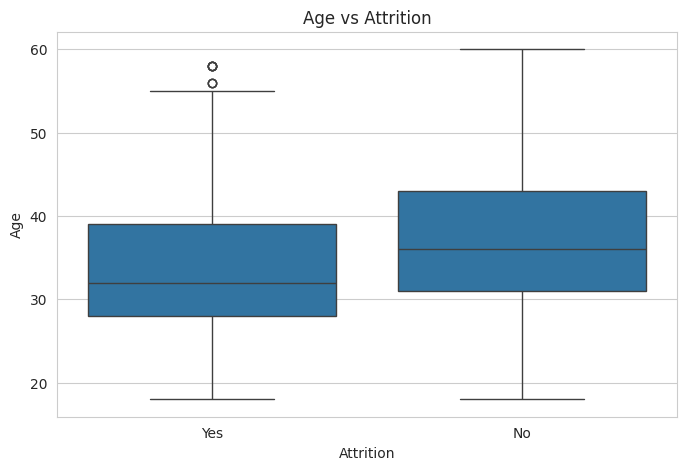

In [36]:
sns.boxplot(
    data=df,
    x="Attrition",
    y="Age"
)

plt.title("Age vs Attrition")
plt.show()

Work-Life Balance

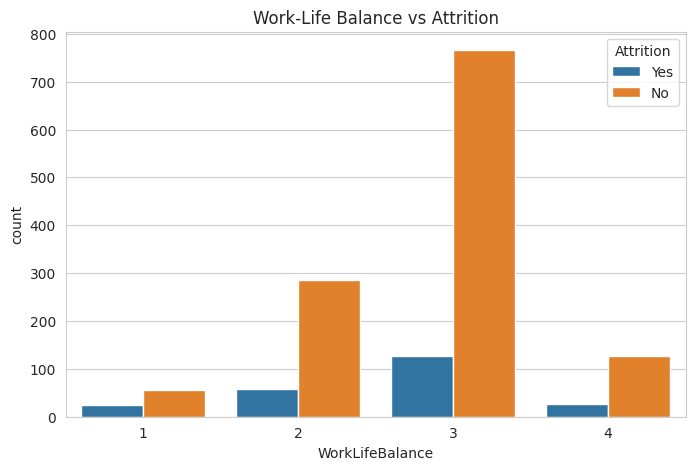

In [37]:
sns.countplot(
    data=df,
    x="WorkLifeBalance",
    hue="Attrition"
)

plt.title("Work-Life Balance vs Attrition")
plt.show()

Job Satisfaction

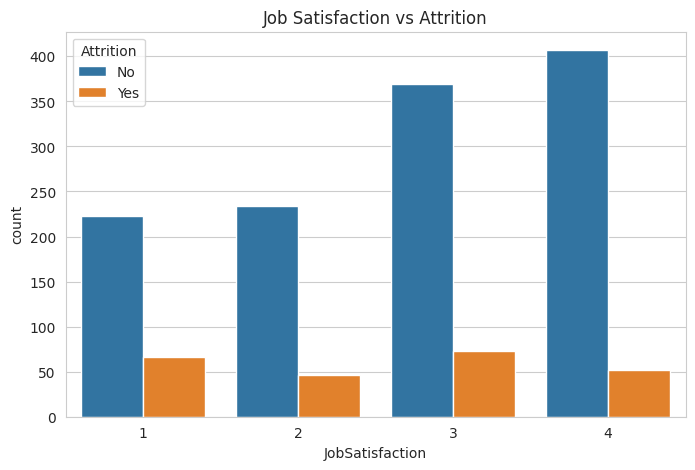

In [38]:
sns.countplot(
    data=df,
    x="JobSatisfaction",
    hue="Attrition"
)

plt.title("Job Satisfaction vs Attrition")
plt.show()

Years at Company

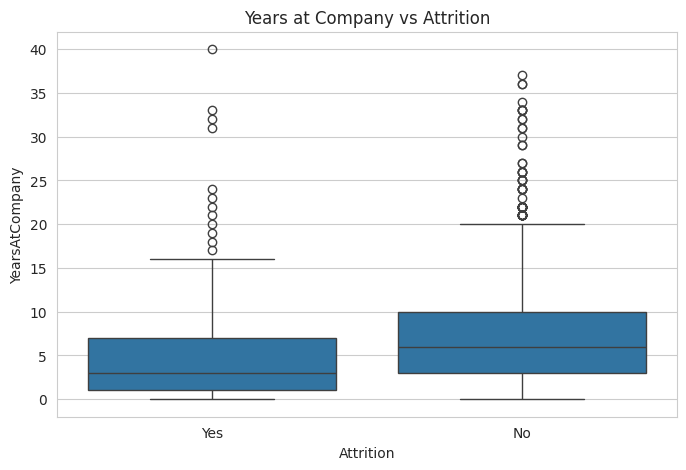

In [39]:
sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsAtCompany"
)

plt.title("Years at Company vs Attrition")
plt.show()

Years Since Last Promotion

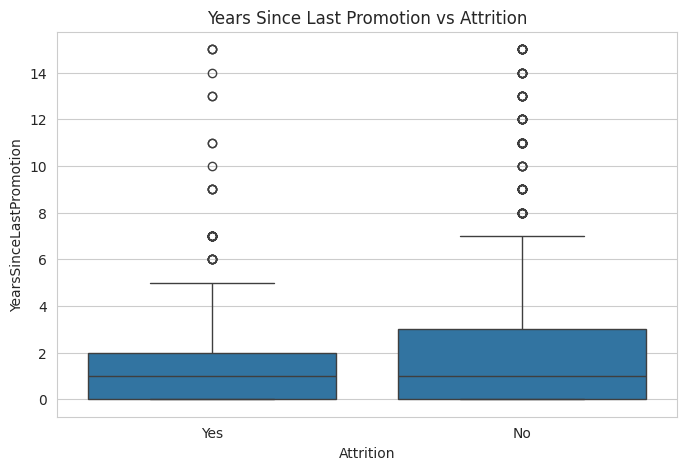

In [40]:
sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsSinceLastPromotion"
)

plt.title("Years Since Last Promotion vs Attrition")
plt.show()

Correlation Heatmap

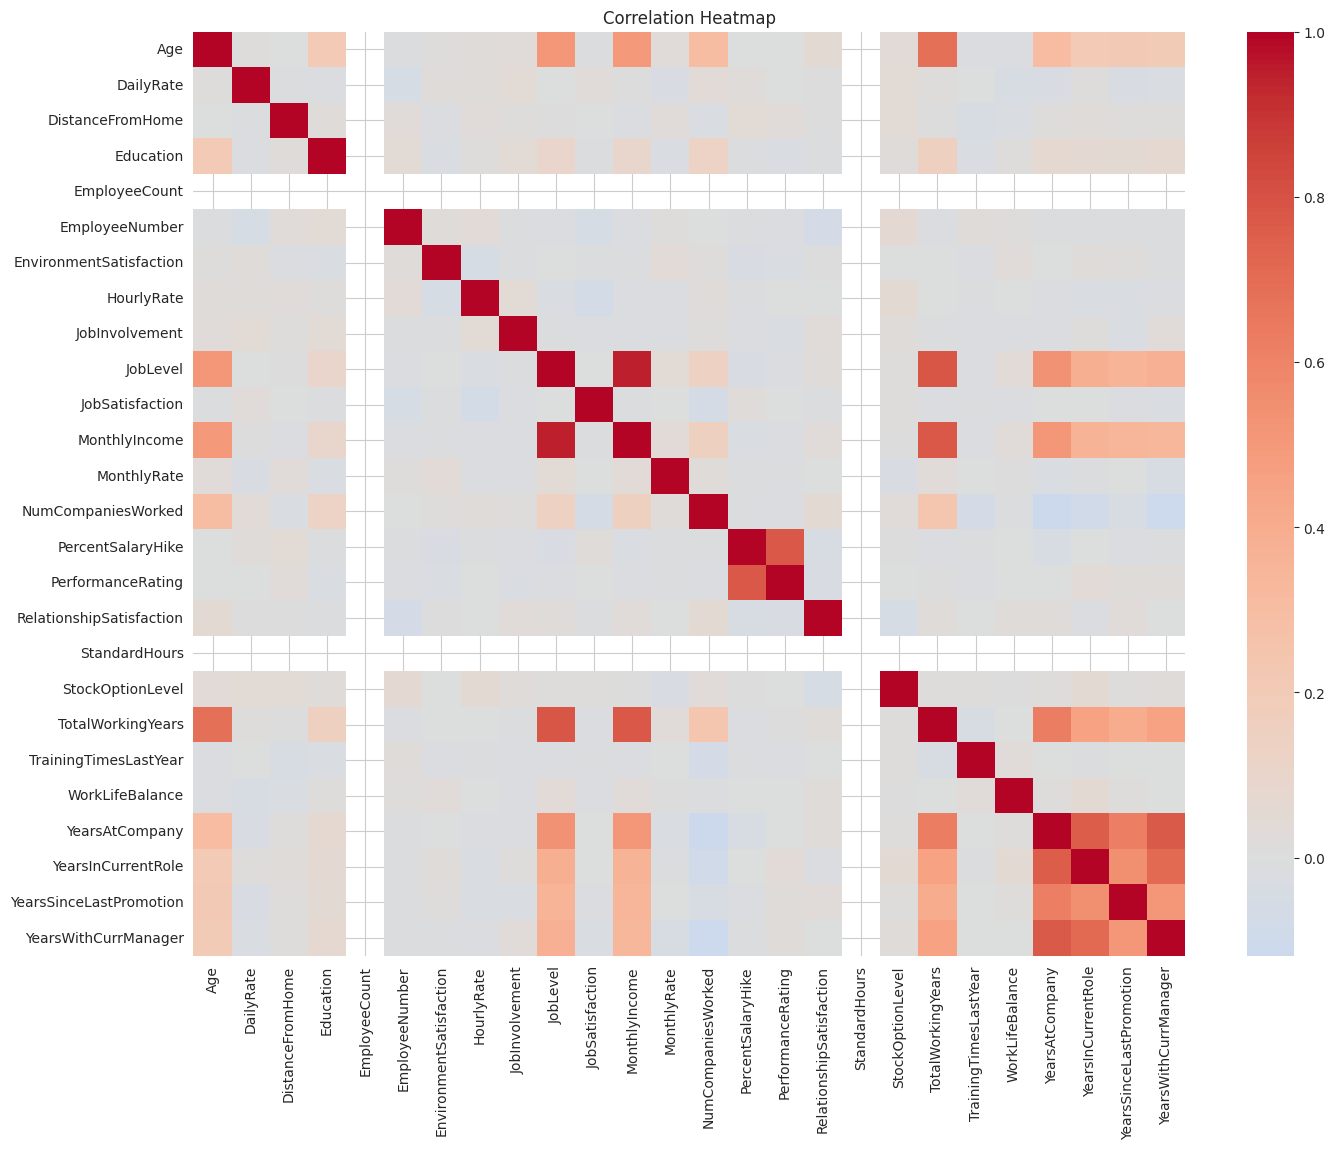

In [41]:
plt.figure(figsize=(16,12))

corr = df.select_dtypes(include=["number"]).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

Pairwise Relationship

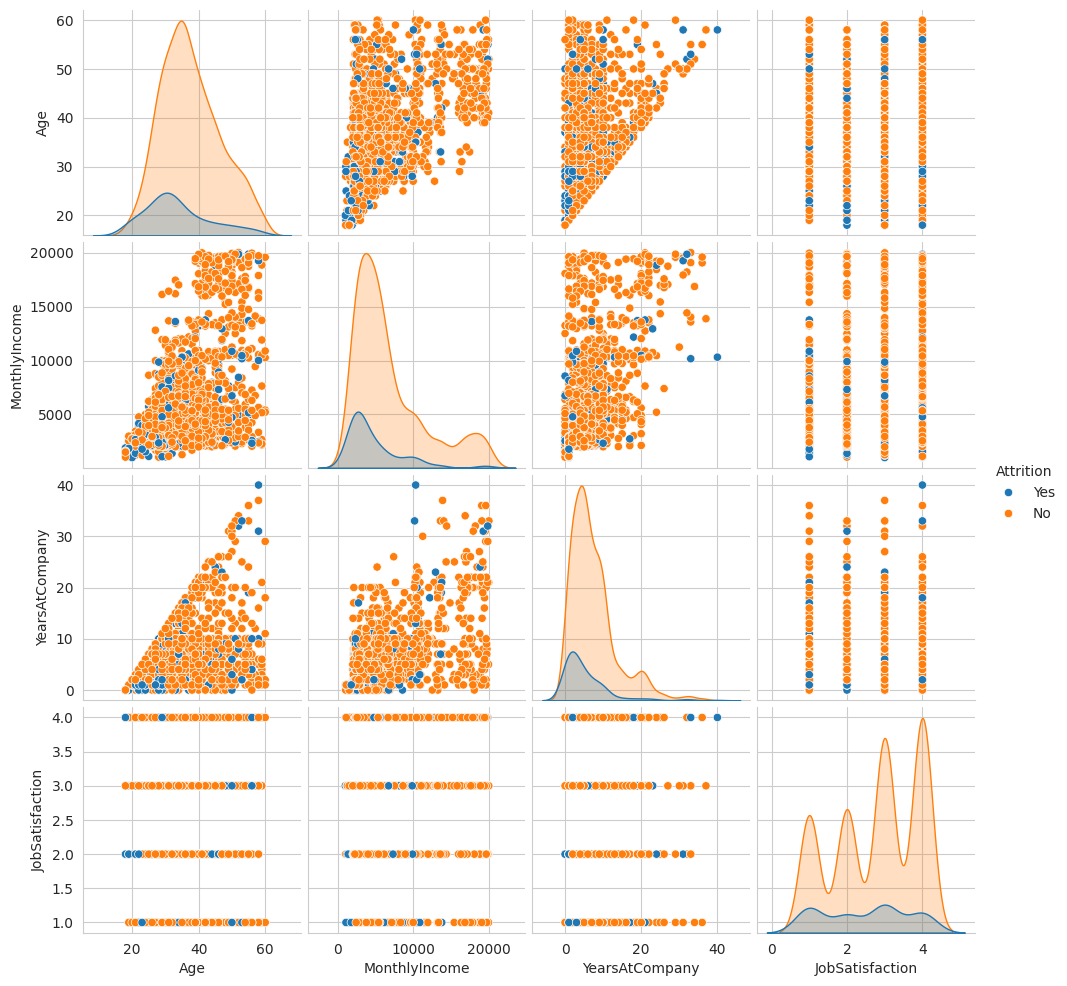

In [42]:
sns.pairplot(
    df[
        [
            "Age",
            "MonthlyIncome",
            "YearsAtCompany",
            "JobSatisfaction",
            "Attrition"
        ]
    ],
    hue="Attrition"
)

Summary Statistics by Attrition

In [43]:
df.groupby("Attrition").mean(numeric_only=True)

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Attrition,,,,,,,,,,,,,,,,,,,,,
No,37.561233,812.504461,8.915653,2.927007,1.0,1027.656123,2.771290,65.952149,2.770479,2.145985,...,2.733982,80.0,0.845093,11.862936,2.832928,2.781022,7.369019,4.484185,2.234388,4.367397
Yes,33.607595,750.362869,10.632911,2.839662,1.0,1010.345992,2.464135,65.573840,2.518987,1.637131,...,2.599156,80.0,0.527426,8.244726,2.624473,2.658228,5.130802,2.902954,1.945148,2.852321


Data Preprocessing

Objective: Convert the raw data into a format suitable for ML models.

Create a Copy of the Dataset

In [44]:
df_ml = df.copy()

Check Categorical Columns

In [45]:
categorical_cols = df_ml.select_dtypes(include="object").columns
print(categorical_cols)

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


Encode the Target Variable

In [46]:
df_ml["Attrition"] = df_ml["Attrition"].map({"No": 0, "Yes": 1})

In [47]:
df_ml["Attrition"].value_counts()

,count
Attrition,
0,1233
1,237


One-Hot Encode Categorical Features

In [48]:
df_ml = pd.get_dummies(
    df_ml,
    drop_first=True
)

In [49]:
print(df_ml.shape)

(1470, 48)


The number of columns will increase because categorical variables are converted into binary features.

Separate Features and Target

In [50]:
X = df_ml.drop("Attrition", axis=1)

y = df_ml["Attrition"]

In [51]:
print(X.shape)
print(y.shape)

(1470, 47)
(1470,)


Train-Test Split

Use a stratified split to preserve the class distribution.

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data :", X_train.shape)
print("Testing data :", X_test.shape)

Training data : (1176, 47)
Testing data : (294, 47)


Feature Scaling

Scaling benefits models like Logistic Regression and SVM, though tree-based models (Random Forest, XGBoost) do not require it.

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Handle Class Imbalance with SMOTE

Apply SMOTE only to the training data to avoid data leakage.

In [55]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [56]:
print(y_train.value_counts())

print(y_train_smote.value_counts())

Attrition
0    986
1    190
Name: count, dtype: int64
Attrition
0    986
1    986
Name: count, dtype: int64


Final Check

In [57]:
print("Training Features:", X_train_smote.shape)
print("Training Labels:", y_train_smote.shape)

print("Testing Features:", X_test_scaled.shape)
print("Testing Labels:", y_test.shape)

Training Features: (1972, 47)
Training Labels: (1972,)
Testing Features: (294, 47)
Testing Labels: (294,)


Model Training

Train Random Forest

In [58]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_estimators=200, random_state=42)

In [97]:
import joblib

# Save the trained Random Forest model
joblib.dump(rf_model, "employee_attrition_model.pkl")

print("✅ Random Forest model saved successfully!")

✅ Random Forest model saved successfully!


In [98]:
from google.colab import files

files.download("employee_attrition_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Make Predictions

In [59]:
# Predict class
y_pred = rf_model.predict(X_test_scaled)

# Predict probability
y_prob = rf_model.predict_proba(X_test_scaled)[:,1]

Evaluate the Model

In [60]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8299319727891157
Precision: 0.43478260869565216
Recall   : 0.2127659574468085
F1 Score : 0.2857142857142857
ROC AUC  : 0.799078301317943


Classification Report

In [61]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.95      0.90       247
           1       0.43      0.21      0.29        47

    accuracy                           0.83       294
   macro avg       0.65      0.58      0.59       294
weighted avg       0.79      0.83      0.80       294



Confusion Matrix

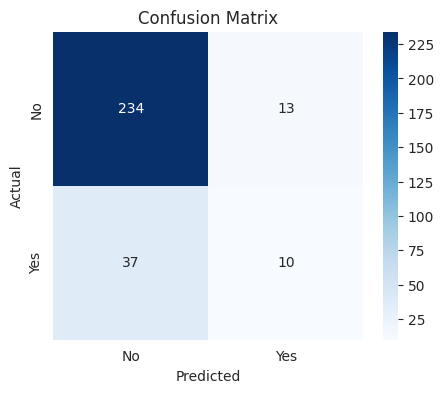

In [63]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No','Yes'],
    yticklabels=['No','Yes']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

ROC Curve

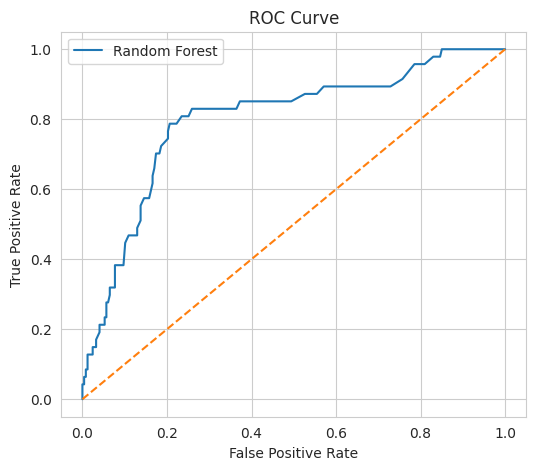

In [64]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Feature Importance ⭐

This is one of the most important parts of your Microsoft showcase project.

In [65]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
46,OverTime_Yes,0.081996
25,YearsWithCurrManager,0.055109
18,StockOptionLevel,0.051714
10,JobSatisfaction,0.044436
11,MonthlyIncome,0.043985
9,JobLevel,0.043745
23,YearsInCurrentRole,0.039848
0,Age,0.039381
19,TotalWorkingYears,0.037649
22,YearsAtCompany,0.035746


Plot Top 15 Important Features

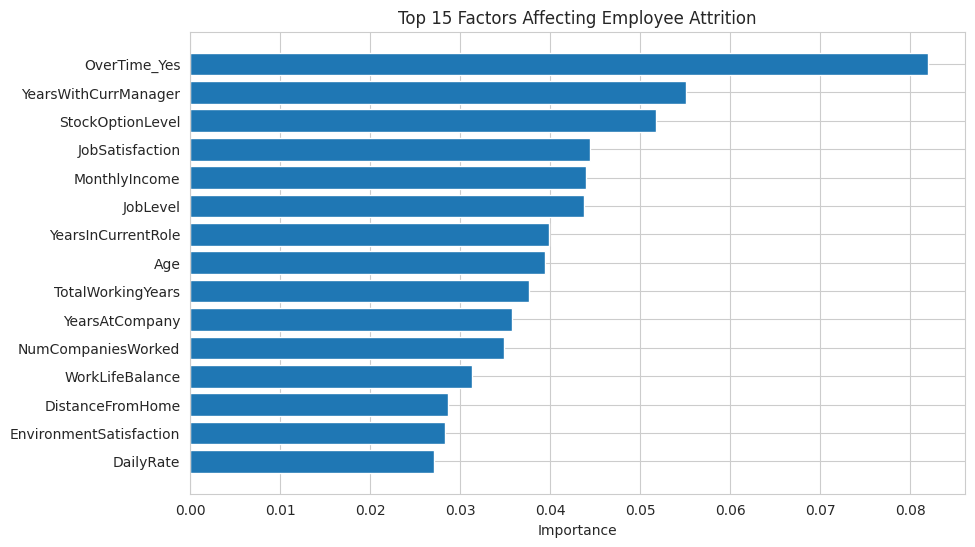

In [66]:
top15 = importance.head(15)

plt.figure(figsize=(10,6))
plt.barh(top15["Feature"], top15["Importance"])
plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Top 15 Factors Affecting Employee Attrition")
plt.show()

Model 2: XGBoost Classifier

Import XGBoost

In [68]:
!pip install xgboost
from xgboost import XGBClassifier

Train the XGBoost Model

In [69]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

Make Predictions

In [70]:
y_pred_xgb = xgb_model.predict(X_test_scaled)

y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:,1]

Evaluate XGBoost

In [71]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_xgb))

Accuracy : 0.8673469387755102
Precision: 0.7
Recall   : 0.2978723404255319
F1 Score : 0.417910447761194
ROC AUC  : 0.7872340425531915


Classification Report

In [72]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       247
           1       0.70      0.30      0.42        47

    accuracy                           0.87       294
   macro avg       0.79      0.64      0.67       294
weighted avg       0.85      0.87      0.84       294



Confusion Matrix

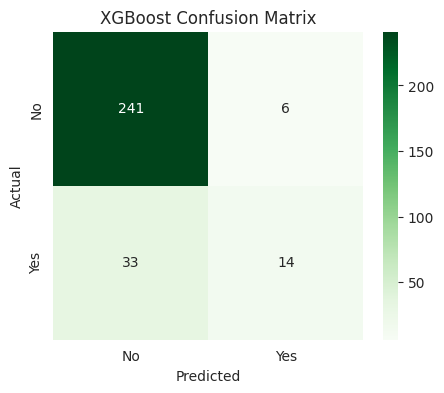

In [73]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No','Yes'],
    yticklabels=['No','Yes']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

Compare Both Models

In [74]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,0.829932,0.434783,0.212766,0.285714,0.799078
1,XGBoost,0.867347,0.700000,0.297872,0.417910,0.787234


Visualize the Comparison

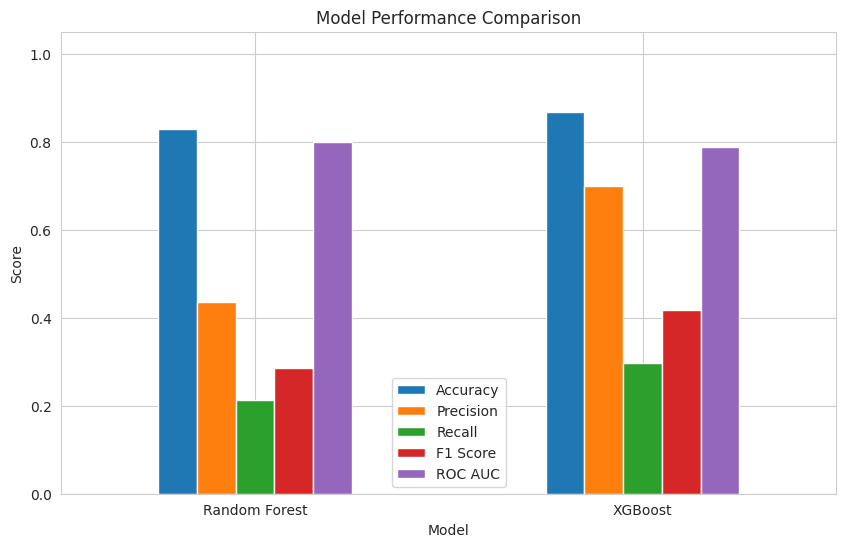

In [75]:
comparison.set_index("Model")[["Accuracy","Precision","Recall","F1 Score","ROC AUC"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.xticks(rotation=0)
plt.show()

Feature Importance (Best Model)

In [76]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
46,OverTime_Yes,0.119410
18,StockOptionLevel,0.064400
9,JobLevel,0.060106
25,YearsWithCurrManager,0.054483
15,PerformanceRating,0.048661
19,TotalWorkingYears,0.035011
40,JobRole_Research Director,0.034094
45,MaritalStatus_Single,0.033235
10,JobSatisfaction,0.032420
41,JobRole_Research Scientist,0.029563


Plot Top 20 Features

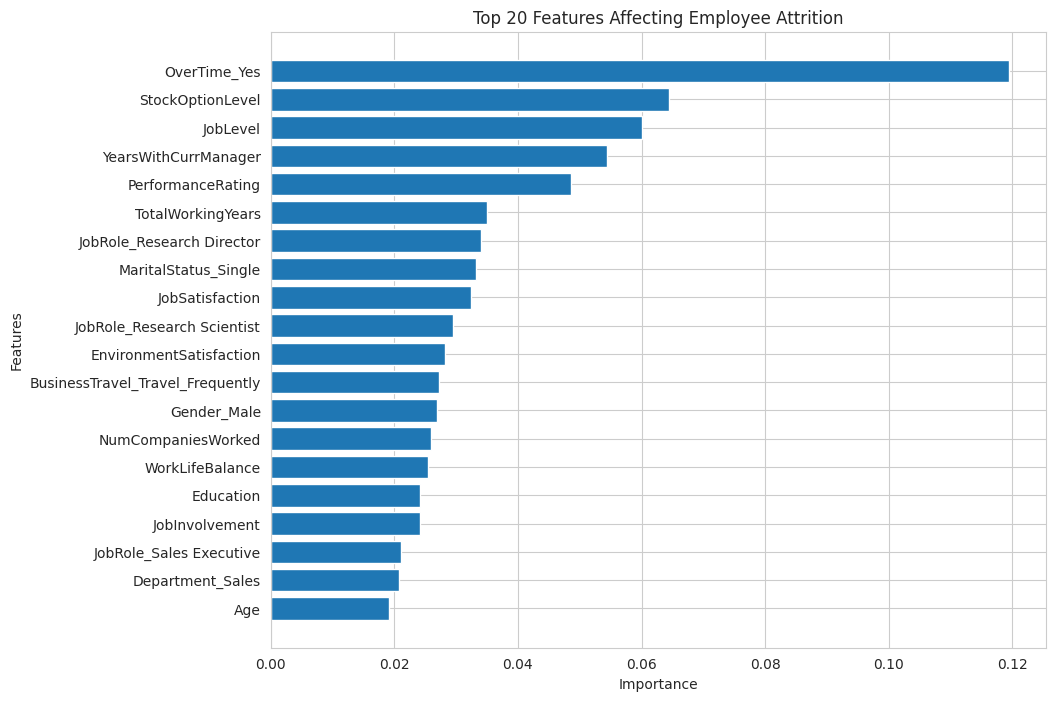

In [77]:
import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(10,8))

plt.barh(top20["Feature"], top20["Importance"])

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 20 Features Affecting Employee Attrition")

plt.show()

Save the Best Model

In [78]:
import joblib

joblib.dump(xgb_model, "employee_attrition_model.pkl")

['employee_attrition_model.pkl']

In [79]:
joblib.dump(X.columns.tolist(), "feature_names.pkl")

['feature_names.pkl']

In [95]:
from google.colab import files


files.download("feature_names.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Test the Saved Model

In [81]:
loaded_model = joblib.load("employee_attrition_model.pkl")

prediction = loaded_model.predict(X_test_scaled[:5])

print(prediction)

[0 0 0 0 0]


Save Label Encoder

In [88]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(df["Attrition"])

In [89]:
import joblib

joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [90]:
from google.colab import files

files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>